<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/01_Breast_Cancer_Logistic_Regression_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [278]:
#Breast cancer prediction using Logistic regression from scratch

In [279]:
# Import the dataset and libraries
import numpy as np
from sklearn.datasets import load_breast_cancer # dataset
from sklearn.preprocessing import StandardScaler # feature scaling
import pandas as pd
import matplotlib.pyplot as plt

In [280]:

# Representation of Data
data = load_breast_cancer() # dataset stored in the variable data.

X = data.data  #input features
Y = data.target  # output labels
#data is a dictionary like object called as bunch in sklearn
scaler = StandardScaler() # Scaler object
X = scaler.fit_transform(X) # Fit and transform the data

print(data.keys()) # it lists all sections inside the dataset
print(data.feature_names) # lists the names of the features

print(X.shape) # Size of the features in format (no. Of rows, no. Of columns)
print(Y.shape) # Size of the target values
print(data.target_names) # names if the target i.e malignant, benign
y = data.target  # output labels
df = pd.DataFrame(X, columns=data.feature_names) # Forms a table listing input features X and columns feature_names
df['target'] = Y # target column in table
df.head()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
(569, 30)
(569,)
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


In [281]:
#Sigmoid Function
def sigmoid(z):
  return 1/ (1 + np.exp(-z))
print(sigmoid(0)) # threshold point where the probability is 50-50.
# There will happen the decision boundary for binary classification

0.5


In [282]:
#Initializing the parameters w and b.
w = np.zeros(X.shape[1]) #Create a weight for each feature, start all at 0, and store them in an array called w
b = 0
lam = 0.1  #penalty
learning_rate = 0.1 # learning rate
iterations = 1000

z = np.dot(X,w + b) # linear combination

Y_pred = sigmoid(z) # predicted possibilities
print(Y_pred[:5]) # first five predictions
# As w and b are 0 so all the predictions are 0.5

[0.5 0.5 0.5 0.5 0.5]


In [283]:
# Calculating  Regularized Loss
m = Y.shape[0] # number of samples
def compute_regularized_loss(Y , Y_pred, w, lam):

   loss = -(1/m) * np.sum(Y*np.log(Y_pred) + (1-Y)*np.log(1-Y_pred))
   reg_term = (lam/(2*m)) * np.sum(w**2)                # L2 regularization
   return loss + reg_term
loss_history = []
#Training Loop
for i in range(iterations):
   z = np.dot(X, w) + b
   Y_pred = sigmoid(z)
   Y_pred = np.clip(Y_pred, 1e-10, 1-1e-10) #Clip for numerical stability

   # Compute Gradients
   dw = (1/m) * np.dot(X.T, (Y_pred - Y)) + (lam/m) * w  #Used transpose T to make the size of the matrix same for calculation
   db = (1/m) * np.sum(Y_pred - Y)

   # Update Parameters
   w = w - learning_rate * dw
   b = b - learning_rate * db

   #Store loss
   current_loss = compute_regularized_loss(Y, Y_pred, w, lam)
   loss_history.append(current_loss)

   # Print loss every 100 iterations
   if i % 100 == 0:
      print(f"Iteration {i}: Loss = {compute_regularized_loss(Y, Y_pred, w, lam): .4f}")

Iteration 0: Loss =  0.6931
Iteration 100: Loss =  0.1030
Iteration 200: Loss =  0.0850
Iteration 300: Loss =  0.0772
Iteration 400: Loss =  0.0726
Iteration 500: Loss =  0.0695
Iteration 600: Loss =  0.0671
Iteration 700: Loss =  0.0653
Iteration 800: Loss =  0.0639
Iteration 900: Loss =  0.0627


In [284]:
Y_class = (Y_pred >= 0.5).astype(int) # Convert probabilities to class labels
accuracy = np.mean(Y_class == Y) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.77%


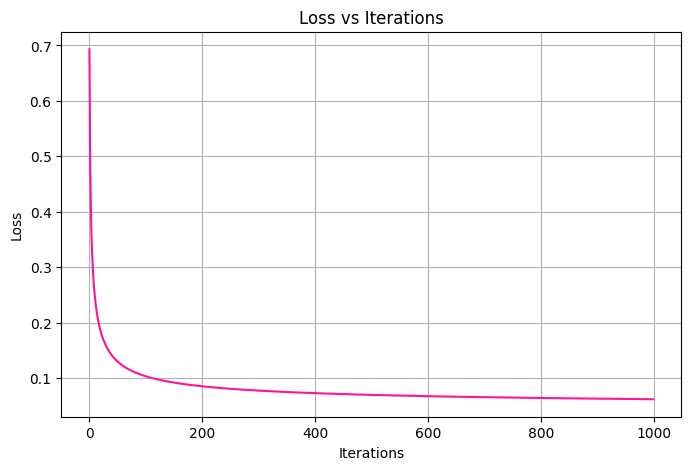

In [285]:
#Plot the loss curve
plt.figure(figsize=(8,5))
plt.plot(range(iterations), loss_history, color = 'deeppink')
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()